In [1]:
import os
import json
import time
import random
import warnings
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T

warnings.filterwarnings('ignore')
%matplotlib inline   

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark     = True   
    torch.backends.cudnn.deterministic = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
    print(f'TF32   : matmul={torch.backends.cuda.matmul.allow_tf32}  '
          f'cudnn={torch.backends.cudnn.allow_tf32}')

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.0 GB
TF32   : matmul=True  cudnn=True


In [3]:
BASE_DIR      = Path.cwd()
DATASET_DIR   = BASE_DIR / 'tiny-imagenet-200'
RESULTS_DIR   = BASE_DIR / 'results'
PROCESSED_DIR = BASE_DIR / 'processed'
RESULTS_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)

TRAIN_DIR  = DATASET_DIR / 'train'
VAL_DIR    = DATASET_DIR / 'val'
VAL_ANNOT  = VAL_DIR / 'val_annotations.txt'
WNIDS_FILE = DATASET_DIR / 'wnids.txt'
STATS_FILE = RESULTS_DIR / 'dataset_stats.json'

In [4]:
if STATS_FILE.exists():
    with open(STATS_FILE) as f:
        s = json.load(f)
    MEAN = tuple(s['rgb_mean'])
    STD  = tuple(s['rgb_std'])
    print(f'Loaded mean/std from {STATS_FILE.name}')
else:
    MEAN = (0.4802, 0.4481, 0.3975)
    STD  = (0.2770, 0.2691, 0.2821)
    print('⚠  dataset_stats.json not found — using published reference values. Run eda.ipynb first!')

print(f'  mean = {MEAN}')
print(f'  std  = {STD}')

with open(WNIDS_FILE) as f:
    wnids = [l.strip() for l in f if l.strip()]

CLASS_MAP   = {wnid: idx for idx, wnid in enumerate(sorted(wnids))}
NUM_CLASSES = len(CLASS_MAP)
print(f'  #classes = {NUM_CLASSES}')

Loaded mean/std from dataset_stats.json
  mean = (0.484623, 0.450968, 0.401014)
  std  = (0.276714, 0.268595, 0.281672)
  #classes = 200


In [5]:
TRAIN_TRANSFORM = T.Compose([
    T.RandomCrop(64, padding=8, padding_mode='reflect'),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.RandomErasing(p=0.2, scale=(0.02, 0.10), ratio=(0.3, 3.3), value=0),
    T.Normalize(mean=MEAN, std=STD),
])

VAL_TRANSFORM = T.Compose([
    T.CenterCrop(56),
    T.Resize(64, interpolation=T.InterpolationMode.BILINEAR, antialias=True),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

print('Augmentation strategy:')
print('  TRAIN : RandomCrop(64,pad=8) | HFlip(0.5) | ColorJitter | RandomGrayscale | RandomErasing(0.2) | Normalize')
print('  VAL   : CenterCrop(56) → Resize(64) | Normalize')

Augmentation strategy:
  TRAIN : RandomCrop(64,pad=8) | HFlip(0.5) | ColorJitter | RandomGrayscale | RandomErasing(0.2) | Normalize
  VAL   : CenterCrop(56) → Resize(64) | Normalize


In [6]:
class TinyImageNetTrain(Dataset):
    """Training split — applies TRAIN_TRANSFORM."""
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return TRAIN_TRANSFORM(img), label


class TinyImageNetVal(Dataset):
    """Validation split — applies VAL_TRANSFORM."""
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return VAL_TRANSFORM(img), label

In [7]:
train_samples: list[tuple[Path, int]] = []
for wnid, label in CLASS_MAP.items():
    img_dir = TRAIN_DIR / wnid / 'images'
    if img_dir.exists():
        for p in img_dir.glob('*.JPEG'):
            train_samples.append((p, label))
random.shuffle(train_samples)

val_samples: list[tuple[Path, int]] = []
img_dir_val = VAL_DIR / 'images'
with open(VAL_ANNOT) as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2 and parts[1] in CLASS_MAP:
            val_samples.append((img_dir_val / parts[0], CLASS_MAP[parts[1]]))

print(f'Train samples : {len(train_samples):,}')
print(f'Val   samples : {len(val_samples):,}')

Train samples : 100,000
Val   samples : 10,000


In [8]:
train_manifest = [(str(p), lbl) for p, lbl in train_samples]
val_manifest   = [(str(p), lbl) for p, lbl in val_samples]

manifest = {
    'train':       train_manifest,
    'val':         val_manifest,
    'class_map':   CLASS_MAP,
    'mean':        list(MEAN),
    'std':         list(STD),
    'num_classes': NUM_CLASSES,
}

manifest_path = PROCESSED_DIR / 'data_manifest.pkl'
with open(manifest_path, 'wb') as f:
    pickle.dump(manifest, f)

summary = {
    'train_samples': len(train_manifest),
    'val_samples':   len(val_manifest),
    'num_classes':   NUM_CLASSES,
    'mean':          list(MEAN),
    'std':           list(STD),
}
with open(PROCESSED_DIR / 'manifest_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'✓  Manifest saved  → {manifest_path}')
print(f'✓  Summary saved   → {PROCESSED_DIR / "manifest_summary.json"}')
print(json.dumps(summary, indent=2))

✓  Manifest saved  → c:\Computer Science\AIMLDL\adaptive-edge-nas\processed\data_manifest.pkl
✓  Summary saved   → c:\Computer Science\AIMLDL\adaptive-edge-nas\processed\manifest_summary.json
{
  "train_samples": 100000,
  "val_samples": 10000,
  "num_classes": 200,
  "mean": [
    0.484623,
    0.450968,
    0.401014
  ],
  "std": [
    0.276714,
    0.268595,
    0.281672
  ]
}


In [9]:
BATCH_SIZE  = 128
NUM_WORKERS = min(6, max(1, (os.cpu_count() or 4) - 1))
PIN_MEMORY  = DEVICE.type == 'cuda'

train_ds = TinyImageNetTrain(train_samples)
val_ds   = TinyImageNetVal(val_samples)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
    drop_last=False,
)

print('DataLoader config:')
print(f'  num_workers = {NUM_WORKERS} | pin_memory = {PIN_MEMORY}')
print(f'  batch_size  = {BATCH_SIZE}  | drop_last (train) = True')
print(f'  train batches : {len(train_loader)} | val batches : {len(val_loader)}')

DataLoader config:
  num_workers = 3 | pin_memory = True
  batch_size  = 128  | drop_last (train) = True
  train batches : 781 | val batches : 79


Generating augmentation preview …


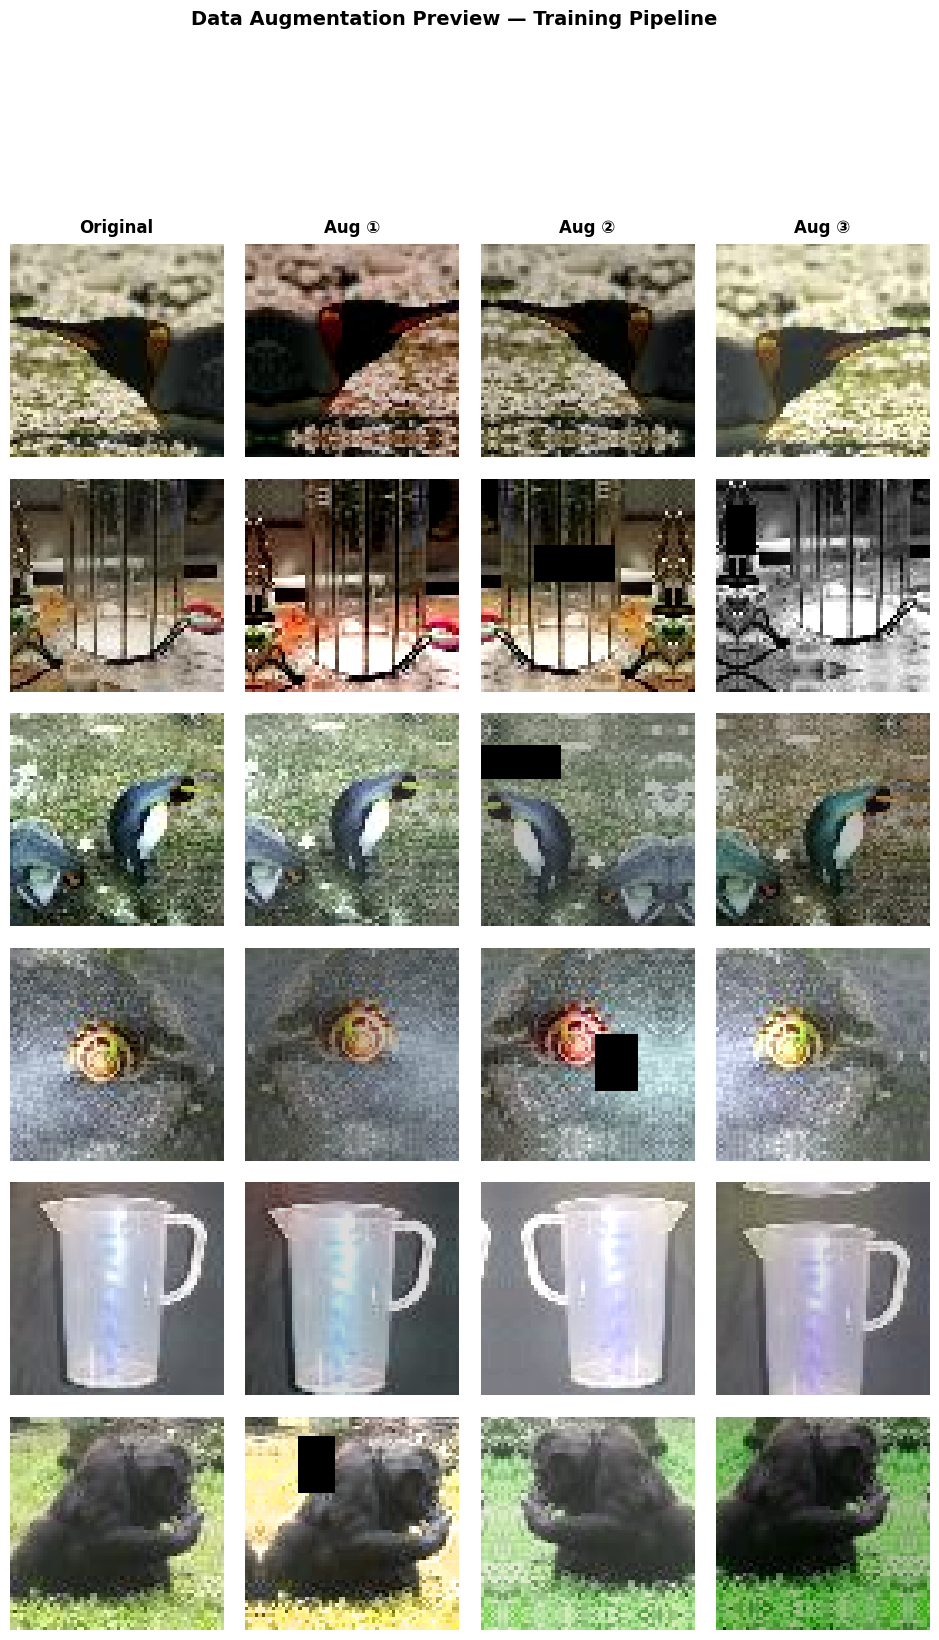

In [10]:
print('Generating augmentation preview …')

N_SAMPLES = 6
indices   = random.sample(range(len(train_samples)), N_SAMPLES)

fig, axes = plt.subplots(N_SAMPLES, 4, figsize=(12, N_SAMPLES * 3),
                          gridspec_kw={'hspace': 0.1, 'wspace': 0.05})
for col, title in enumerate(['Original', 'Aug ①', 'Aug ②', 'Aug ③']):
    axes[0, col].set_title(title, fontsize=12, pad=8, fontweight='bold')

_mean_t = torch.tensor(MEAN).view(3, 1, 1)
_std_t  = torch.tensor(STD).view(3, 1, 1)

for row, idx in enumerate(indices):
    path, _ = train_samples[idx]
    pil_img  = Image.open(path).convert('RGB')

    # Original (un-augmented)
    raw = (T.ToTensor()(pil_img).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    axes[row, 0].imshow(raw)
    axes[row, 0].axis('off')

    # Three augmented views (denormalized for display)
    for col in range(1, 4):
        aug    = TRAIN_TRANSFORM(pil_img)
        denorm = ((aug * _std_t + _mean_t).clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        axes[row, col].imshow(denorm)
        axes[row, col].axis('off')

fig.suptitle('Data Augmentation Preview — Training Pipeline',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig(RESULTS_DIR / 'augmentation_preview.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(f'Benchmarking DataLoader (batch={BATCH_SIZE}, 20 batches) …')

loader_iter = iter(train_loader)
_ = next(loader_iter)   # warm-up

t0, n_imgs = time.perf_counter(), 0
for _ in range(min(20, len(train_loader))):
    imgs, _ = next(loader_iter)
    n_imgs += imgs.shape[0]
elapsed    = time.perf_counter() - t0
throughput = n_imgs / elapsed

bm = {
    'batch_size':       BATCH_SIZE,
    'num_workers':      NUM_WORKERS,
    'n_batches':        20,
    'total_images':     n_imgs,
    'elapsed_sec':      round(elapsed, 3),
    'throughput_img_s': round(throughput, 1),
}

print(f'  Throughput : {throughput:,.0f} imgs/sec')
print(f'  Workers    : {NUM_WORKERS}')
print(f'  Elapsed    : {elapsed:.2f}s for {n_imgs:,} images')

with open(RESULTS_DIR / 'dataloader_benchmark.json', 'w') as f:
    json.dump(bm, f, indent=2)
print('Saved → dataloader_benchmark.json')

Benchmarking DataLoader (batch=128, 20 batches) …
